In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED  = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEPHORA_COLOR  = "#E91E63"
ULTA_COLOR     = "#9C27B0"
SPILLOVER_COLOR = "#FF5722"
NEUTRAL_COLOR  = "#607D8B"
POSITIVE_COLOR = "#4CAF50"
WARNING_COLOR  = "#FF9800"

In [5]:
sephora_seg = pd.read_csv(PROCESSED / "Sephora" / "sephora_segmentation.csv",
                           dtype={"product_id": str})
ulta_seg    = pd.read_csv(PROCESSED / "Ulta"    / "ulta_segmentation.csv",
                           dtype={"product_id": str})
matched     = pd.read_csv(PROCESSED / "Matched" / "matched_pairs.csv",
                           dtype={"sephora_product_id": str,
                                  "ulta_product_id":    str})

# Time-series (built by build_review_timeseries.py)
s_ts = pd.read_csv(PROCESSED / "Sephora" / "sephora_reviews_timeseries.csv",
                    dtype={"product_id": str})
u_ts = pd.read_csv(PROCESSED / "Ulta"    / "ulta_reviews_timeseries.csv",
                    dtype={"product_id": str})

s_ts["platform"] = "Sephora"
u_ts["platform"] = "Ulta"
all_ts = pd.concat([s_ts, u_ts], ignore_index=True)
all_ts["year_month"] = all_ts["year_month"].astype(str)

# Cluster labels
s_clusters = pd.read_csv(PROCESSED / "Sephora" / "sephora_cluster_labels.csv",
                          dtype={"product_id": str})
u_clusters = pd.read_csv(PROCESSED / "Ulta"    / "ulta_cluster_labels.csv",
                          dtype={"product_id": str})
sephora_seg = sephora_seg.merge(s_clusters, on="product_id", how="left")
ulta_seg    = ulta_seg.merge(u_clusters,    on="product_id", how="left")

# Resolve matched pair ID columns
id_col_s = "sephora_product_id" if "sephora_product_id" in matched.columns \
           else "product_id_sephora"
id_col_u = "ulta_product_id"    if "ulta_product_id"    in matched.columns \
           else "product_id_ulta"
brand_col = "sephora_brand_normalized"

print(f"Matched pairs     : {len(matched):,}")
print(f"Sephora TS rows   : {len(s_ts):,}  |  products: {s_ts['product_id'].nunique():,}")
print(f"Ulta TS rows      : {len(u_ts):,}  |  products: {u_ts['product_id'].nunique():,}")
print(f"Shared months     : {sorted(set(s_ts['year_month']) & set(u_ts['year_month']))[:5]} ...")

Matched pairs     : 379
Sephora TS rows   : 28,693  |  products: 1,641
Ulta TS rows      : 137,858  |  products: 11,227
Shared months     : ['2009-04', '2009-05', '2009-06', '2009-07', '2009-08'] ...


In [8]:
pair_panel = (
    matched[[id_col_s, id_col_u, brand_col]]
    .merge(
        s_ts[["product_id", "year_month", "review_count", "avg_rating",
              "avg_sentiment", "pct_negative", "negative_shock",
              "velocity_3m", "rating_trend"]],
        left_on=id_col_s, right_on="product_id", how="inner"
    )
    .rename(columns={
        "review_count":   "rc_s",
        "avg_rating":     "rating_s",
        "avg_sentiment":  "sent_s",
        "pct_negative":   "neg_s",
        "negative_shock": "shock_s",
        "velocity_3m":    "vel3m_s",
        "rating_trend":   "rtrend_s",
    })
    .drop(columns=["product_id"])
    .merge(
        u_ts[["product_id", "year_month", "review_count", "avg_rating",
              "avg_sentiment", "pct_negative", "negative_shock",
              "velocity_3m", "rating_trend"]],
        left_on=[id_col_u, "year_month"], right_on=["product_id", "year_month"],
        how="inner"
    )
    .rename(columns={
        "review_count":   "rc_u",
        "avg_rating":     "rating_u",
        "avg_sentiment":  "sent_u",
        "pct_negative":   "neg_u",
        "negative_shock": "shock_u",
        "velocity_3m":    "vel3m_u",
        "rating_trend":   "rtrend_u",
    })
    .drop(columns=["product_id"])
)

pair_panel = pair_panel.sort_values([brand_col, "year_month"]).reset_index(drop=True)

# Lags: Sephora shock → Ulta velocity next month (and vice versa)
pair_panel["shock_s_lag1"] = (pair_panel.groupby(brand_col)["shock_s"]
                               .shift(1).fillna(0))
pair_panel["shock_u_lag1"] = (pair_panel.groupby(brand_col)["shock_u"]
                               .shift(1).fillna(0))
pair_panel["vel_s_lag1"]   = pair_panel.groupby(brand_col)["rc_s"].shift(1)
pair_panel["vel_u_lag1"]   = pair_panel.groupby(brand_col)["rc_u"].shift(1)

print(f"Matched-pair panel: {len(pair_panel):,} rows  |  "
      f"{pair_panel[brand_col].nunique():,} brands  |  "
      f"months: {pair_panel['year_month'].nunique()}")

Matched-pair panel: 3,279 rows  |  110 brands  |  months: 103


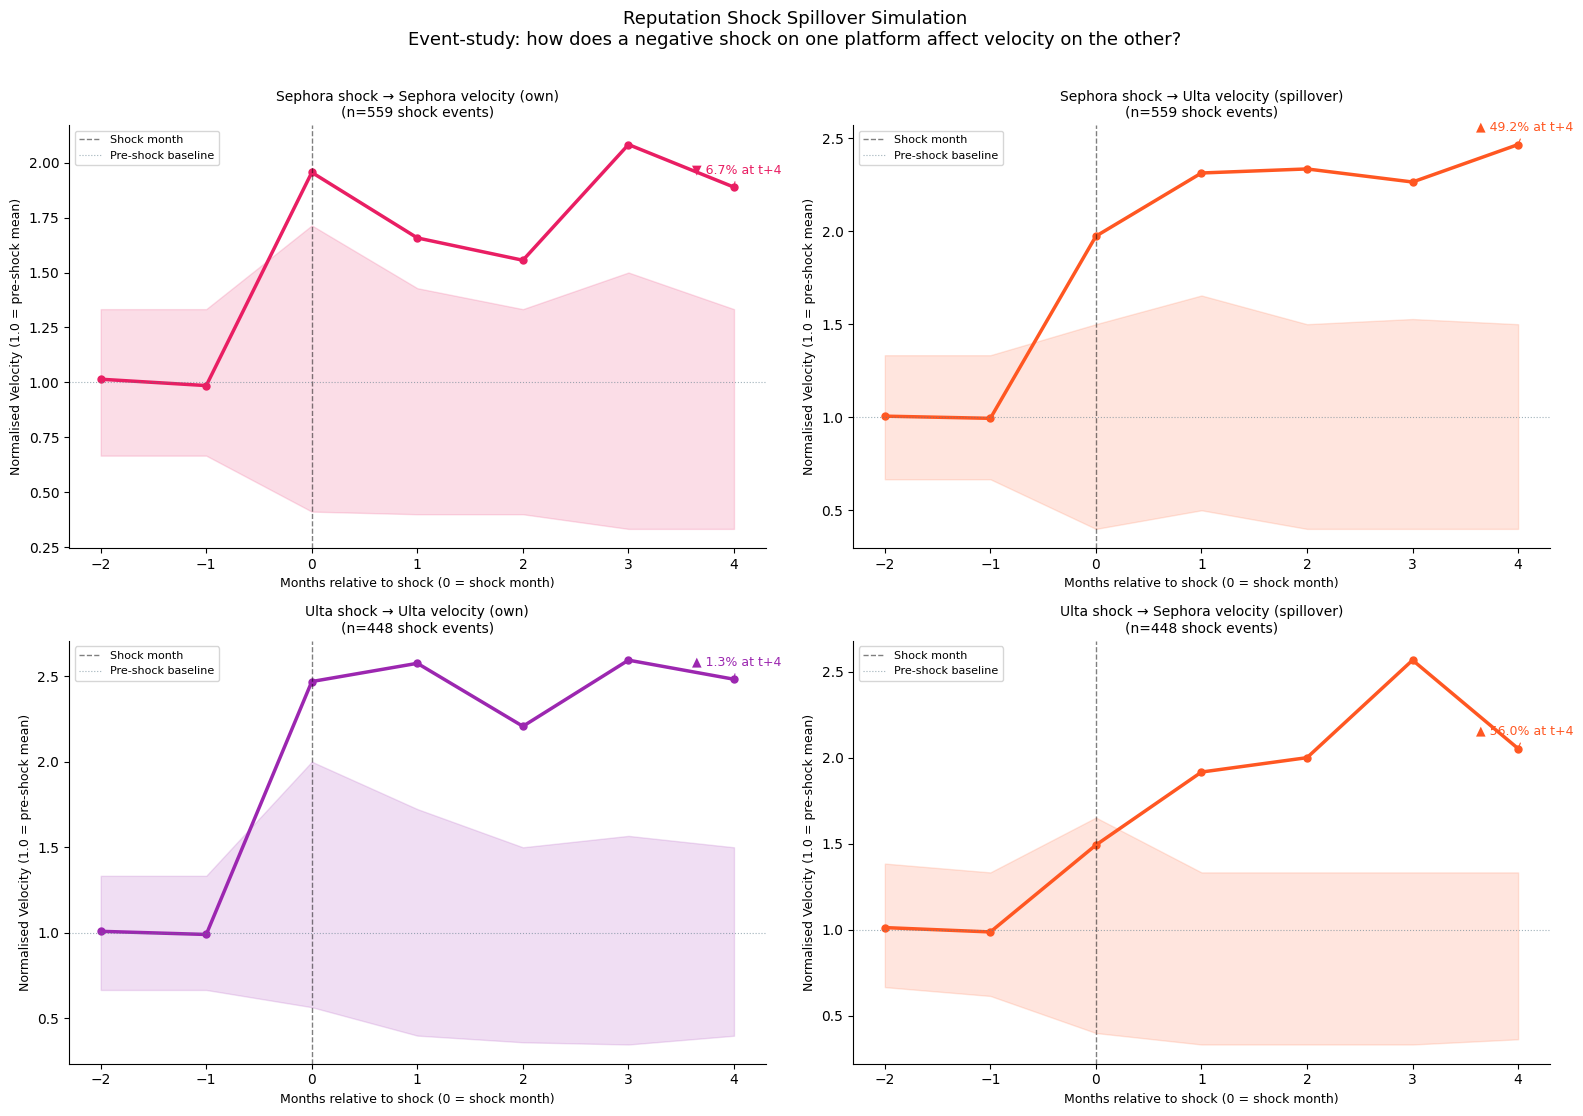

In [9]:
def spillover_response(panel, shock_col, response_col, brand_col,
                        window_before=2, window_after=4):
    """
    Event-study around shock months.
    Returns average normalised velocity trajectory centred on shock month=0.
    """
    records = []
    for brand, grp in panel.groupby(brand_col):
        grp = grp.sort_values("year_month").reset_index(drop=True)
        shock_idx = grp.index[grp[shock_col] == 1].tolist()
        for idx in shock_idx:
            start = idx - window_before
            end   = idx + window_after + 1
            if start < 0 or end > len(grp):
                continue
            window = grp.iloc[start:end][response_col].values.astype(float)
            # Normalise to pre-shock mean
            pre_mean = window[:window_before].mean()
            if pre_mean > 0:
                window_n = window / pre_mean
                records.append(window_n)
    if not records:
        return None
    arr = np.array(records)
    return {
        "mean":   arr.mean(axis=0),
        "ci_lo":  np.percentile(arr, 25, axis=0),
        "ci_hi":  np.percentile(arr, 75, axis=0),
        "n":      len(records),
    }

window_b, window_a = 2, 4
t_axis = list(range(-window_b, window_a + 1))

# Four spillover directions
spillovers = {
    "Sephora shock → Sephora velocity (own)":
        spillover_response(pair_panel, "shock_s", "rc_s",    brand_col, window_b, window_a),
    "Sephora shock → Ulta velocity (spillover)":
        spillover_response(pair_panel, "shock_s", "rc_u",    brand_col, window_b, window_a),
    "Ulta shock → Ulta velocity (own)":
        spillover_response(pair_panel, "shock_u", "rc_u",    brand_col, window_b, window_a),
    "Ulta shock → Sephora velocity (spillover)":
        spillover_response(pair_panel, "shock_u", "rc_s",    brand_col, window_b, window_a),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=False)
axes = axes.flatten()

for ax, (label, result) in zip(axes, spillovers.items()):
    if result is None:
        ax.text(0.5, 0.5, "Insufficient shock events",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=11, color=NEUTRAL_COLOR)
        ax.set_title(label, fontsize=10)
        continue

    is_spillover = "spillover" in label
    color        = SPILLOVER_COLOR if is_spillover else \
                   (SEPHORA_COLOR if "Sephora shock →" in label else ULTA_COLOR)

    ax.fill_between(t_axis, result["ci_lo"], result["ci_hi"],
                    color=color, alpha=0.15)
    ax.plot(t_axis, result["mean"], color=color, lw=2.5,
            marker="o", markersize=5)
    ax.axvline(0,  color="black",       lw=1,   ls="--", alpha=0.5,
               label="Shock month")
    ax.axhline(1.0, color=NEUTRAL_COLOR, lw=0.8, ls=":",  alpha=0.6,
               label="Pre-shock baseline")

    # Annotate post-shock delta
    post_change = result["mean"][-1] - result["mean"][window_b]
    direction   = "▼" if post_change < 0 else "▲"
    ax.annotate(f"{direction} {abs(post_change)*100:.1f}% at t+{window_a}",
                xy=(window_a, result["mean"][-1]),
                xytext=(-30, 10), textcoords="offset points",
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle="-", color=color, lw=0.8))

    ax.set_xlabel("Months relative to shock (0 = shock month)", fontsize=9)
    ax.set_ylabel("Normalised Velocity (1.0 = pre-shock mean)", fontsize=9)
    ax.set_title(f"{label}\n(n={result['n']} shock events)", fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Reputation Shock Spillover Simulation\n"
             "Event-study: how does a negative shock on one platform affect "
             "velocity on the other?",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.2_spillover_event_study.png",
            dpi=150, bbox_inches="tight")
plt.show()

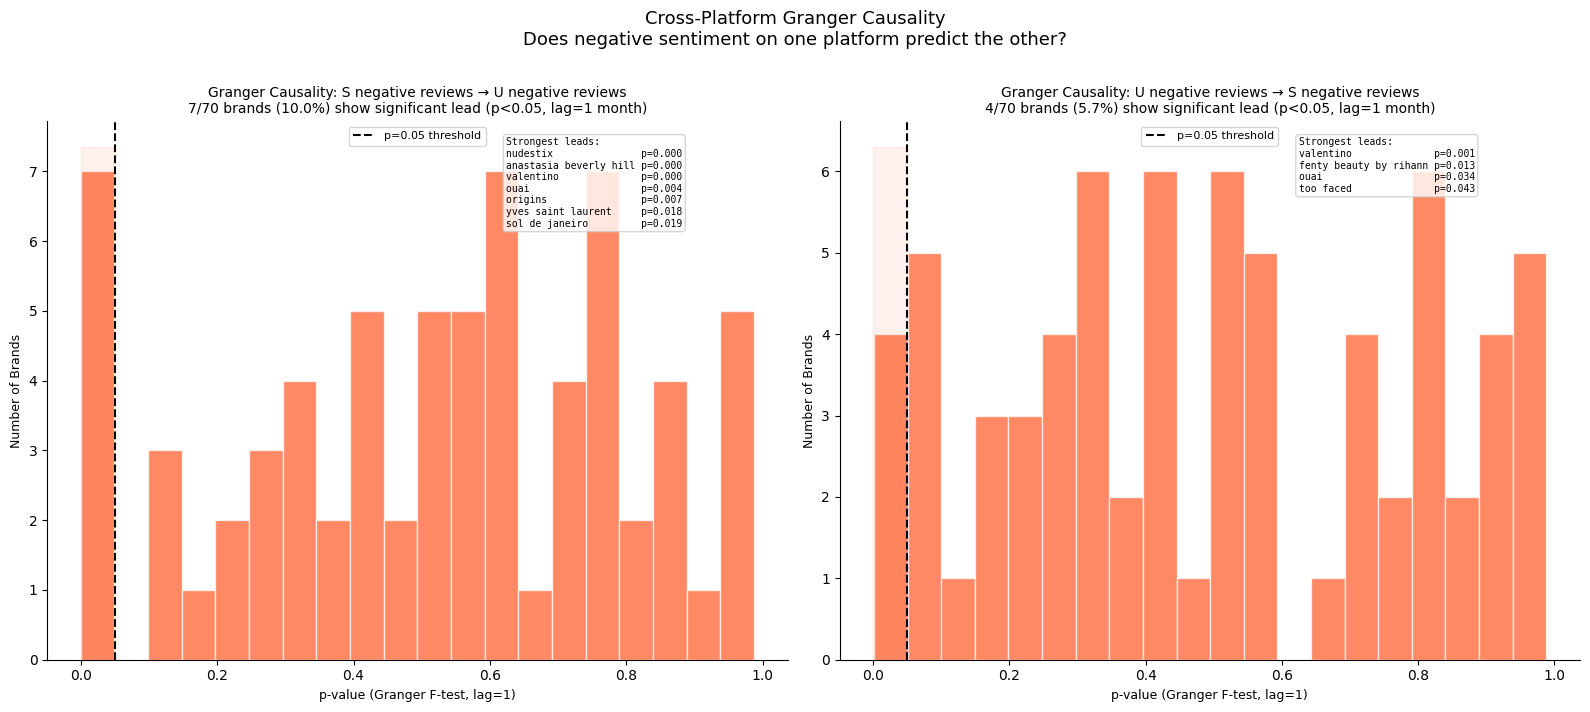

In [10]:
# For each brand with ≥12 months of data on both platforms, test whether
# Sephora pct_negative Granger-causes Ulta pct_negative (and vice versa).

granger_results = {"S→U": [], "U→S": []}

for brand, grp in pair_panel.groupby(brand_col):
    grp = grp.sort_values("year_month").dropna(
        subset=["neg_s", "neg_u"]
    ).reset_index(drop=True)
    if len(grp) < 12:
        continue
    for direction, y_col, x_col in [
        ("S→U", "neg_u", "neg_s"),
        ("U→S", "neg_s", "neg_u"),
    ]:
        try:
            series = grp[[y_col, x_col]].astype(float)
            res    = grangercausalitytests(series, maxlag=2, verbose=False)
            # Take the p-value from lag-1 F-test
            p = res[1][0]["ssr_ftest"][1]
            granger_results[direction].append({
                "brand": brand,
                "p":     p,
                "sig":   p < 0.05,
            })
        except Exception:
            continue

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (direction, results) in zip(axes, granger_results.items()):
    if not results:
        ax.text(0.5, 0.5, "Insufficient data",
                ha="center", va="center", transform=ax.transAxes)
        continue

    df_g   = pd.DataFrame(results)
    n_sig  = df_g["sig"].sum()
    n_tot  = len(df_g)
    pct_sig = n_sig / n_tot * 100

    # P-value distribution
    ax.hist(df_g["p"], bins=20, color=SPILLOVER_COLOR, alpha=0.7,
            edgecolor="white")
    ax.axvline(0.05, color="black", lw=1.5, ls="--",
               label=f"p=0.05 threshold")
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 50],
                     0, 0.05, color=SPILLOVER_COLOR, alpha=0.08)

    src, tgt = direction.split("→")
    ax.set_title(f"Granger Causality: {src} negative reviews → {tgt} negative reviews\n"
                 f"{n_sig}/{n_tot} brands ({pct_sig:.1f}%) show significant lead "
                 f"(p<0.05, lag=1 month)",
                 fontsize=10)
    ax.set_xlabel("p-value (Granger F-test, lag=1)", fontsize=9)
    ax.set_ylabel("Number of Brands",                fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Top brands with strongest lead
    top_lead = df_g[df_g["sig"]].nsmallest(8, "p")
    if len(top_lead) > 0:
        table_text = "\n".join(
            f"{r['brand'][:22]:<22} p={r['p']:.3f}"
            for _, r in top_lead.iterrows()
        )
        ax.text(0.62, 0.97, f"Strongest leads:\n{table_text}",
                transform=ax.transAxes, fontsize=7,
                va="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          alpha=0.8, edgecolor="#ccc"))

fig.suptitle("Cross-Platform Granger Causality\n"
             "Does negative sentiment on one platform predict the other?",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.2_granger_causality.png",
            dpi=150, bbox_inches="tight")
plt.show()

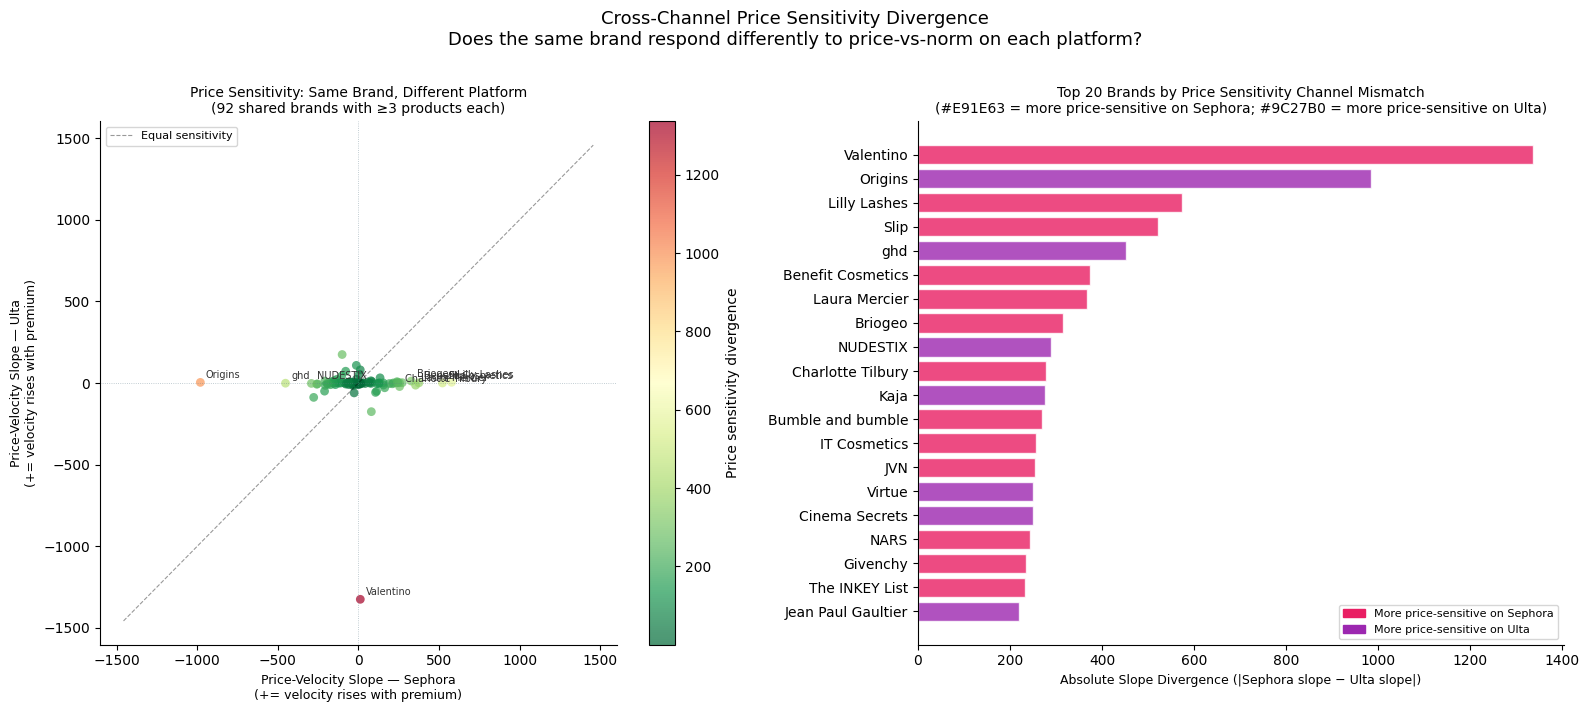

In [11]:
# For each matched brand, compute the price-velocity slope on each platform
# (OLS: velocity ~ price_vs_category_median).
# Plot Sephora slope vs. Ulta slope — brands far from diagonal = channel mismatch.

brand_col_s = "brand_normalized" if "brand_normalized" in sephora_seg.columns \
              else "brand"
brand_col_u = "brand_normalized" if "brand_normalized" in ulta_seg.columns \
              else "brand"

def brand_price_slopes(seg_df, brand_col):
    """OLS slope of reviews_per_month ~ price_vs_category_median per brand."""
    slopes = {}
    if "price_vs_category_median" not in seg_df.columns or \
       "reviews_per_month" not in seg_df.columns:
        return slopes
    for brand, grp in seg_df.groupby(brand_col):
        sub = grp[["price_vs_category_median", "reviews_per_month"]].dropna()
        if len(sub) < 3:
            continue
        try:
            m, _, r, p, _ = stats.linregress(
                sub["price_vs_category_median"],
                sub["reviews_per_month"]
            )
            slopes[brand] = {"slope": m, "r": r, "p": p, "n": len(sub)}
        except Exception:
            continue
    return slopes

slopes_s = brand_price_slopes(sephora_seg, brand_col_s)
slopes_u = brand_price_slopes(ulta_seg,    brand_col_u)

# Join on common brands
common_brands = set(slopes_s) & set(slopes_u)
slope_df = pd.DataFrame([
    {
        "brand":   b,
        "slope_s": slopes_s[b]["slope"],
        "slope_u": slopes_u[b]["slope"],
        "n_s":     slopes_s[b]["n"],
        "n_u":     slopes_u[b]["n"],
    }
    for b in common_brands
    if slopes_s[b]["n"] >= 3 and slopes_u[b]["n"] >= 3
])

if len(slope_df) > 0:
    # Price sensitivity divergence = |slope_s - slope_u|
    slope_df["divergence"] = (slope_df["slope_s"] - slope_df["slope_u"]).abs()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Panel 1: scatter of Sephora slope vs. Ulta slope
    ax = axes[0]
    sc = ax.scatter(
        slope_df["slope_s"], slope_df["slope_u"],
        c=slope_df["divergence"],
        cmap="RdYlGn_r", s=40, alpha=0.7, edgecolors="none",
    )
    plt.colorbar(sc, ax=ax, label="Price sensitivity divergence")

    # Diagonal = equal slopes
    lim = max(slope_df[["slope_s", "slope_u"]].abs().max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.8,
            ls="--", alpha=0.4, label="Equal sensitivity")
    ax.axvline(0, color=NEUTRAL_COLOR, lw=0.6, ls=":", alpha=0.5)
    ax.axhline(0, color=NEUTRAL_COLOR, lw=0.6, ls=":", alpha=0.5)

    # Label top-divergence brands
    for _, row in slope_df.nlargest(10, "divergence").iterrows():
        ax.annotate(row["brand"][:18],
                    xy=(row["slope_s"], row["slope_u"]),
                    xytext=(4, 3), textcoords="offset points",
                    fontsize=7, color="#333")

    ax.set_xlabel("Price-Velocity Slope — Sephora\n(+= velocity rises with premium)",
                  fontsize=9)
    ax.set_ylabel("Price-Velocity Slope — Ulta\n(+= velocity rises with premium)",
                  fontsize=9)
    ax.set_title(f"Price Sensitivity: Same Brand, Different Platform\n"
                 f"({len(slope_df)} shared brands with ≥3 products each)",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Panel 2: top divergence brands ranked
    ax2 = axes[1]
    top20 = slope_df.nlargest(20, "divergence").sort_values("divergence")
    colors = [SEPHORA_COLOR if row["slope_s"] > row["slope_u"]
              else ULTA_COLOR
              for _, row in top20.iterrows()]
    ax2.barh(top20["brand"], top20["divergence"],
             color=colors, alpha=0.8, edgecolor="white")
    ax2.set_xlabel("Absolute Slope Divergence (|Sephora slope − Ulta slope|)",
                   fontsize=9)
    ax2.set_title("Top 20 Brands by Price Sensitivity Channel Mismatch\n"
                  f"({SEPHORA_COLOR} = more price-sensitive on Sephora; "
                  f"{ULTA_COLOR} = more price-sensitive on Ulta)",
                  fontsize=10)

    legend_items = [
        mpatches.Patch(color=SEPHORA_COLOR, label="More price-sensitive on Sephora"),
        mpatches.Patch(color=ULTA_COLOR,    label="More price-sensitive on Ulta"),
    ]
    ax2.legend(handles=legend_items, fontsize=8)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Cross-Channel Price Sensitivity Divergence\n"
                 "Does the same brand respond differently to price-vs-norm "
                 "on each platform?",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_price_sensitivity_divergence.png",
                dpi=150, bbox_inches="tight")
    plt.show()

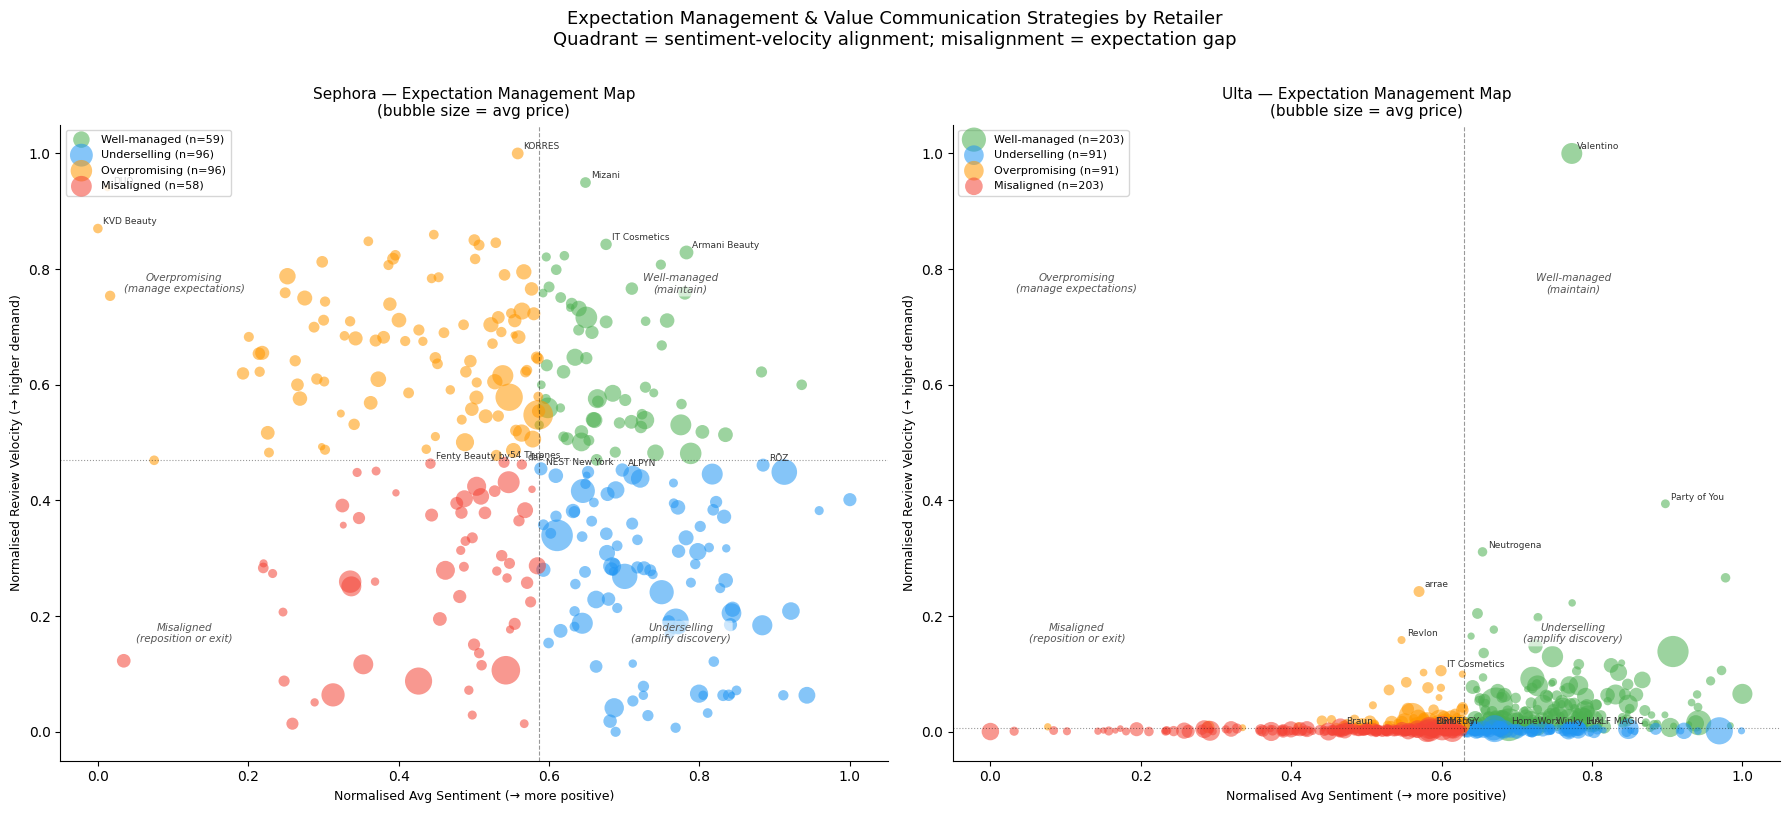

In [12]:
# Classify brands into four expectation management quadrants:
#   High sentiment, high velocity  → Well-managed expectations
#   High sentiment, low velocity   → Underselling (under-discovery)
#   Low sentiment, high velocity   → Overpromising (reputation risk)
#   Low sentiment, low velocity    → Misaligned positioning

def expectation_map(seg_df, platform, color):
    brand_col = "brand_normalized" if "brand_normalized" in seg_df.columns \
                else "brand"
    needed    = [brand_col, "avg_sentiment", "reviews_per_month",
                 "avg_rating", "price"]
    cols      = [c for c in needed if c in seg_df.columns]
    agg = (seg_df[cols]
           .groupby(brand_col)
           .mean(numeric_only=True)
           .reset_index()
           .rename(columns={brand_col: "brand"}))

    if "avg_sentiment" not in agg.columns or \
       "reviews_per_month" not in agg.columns:
        return None

    # Normalise both axes to [0,1]
    for col in ["avg_sentiment", "reviews_per_month"]:
        mn, mx = agg[col].min(), agg[col].max()
        agg[f"{col}_n"] = (agg[col] - mn) / (mx - mn + 1e-9)

    # Classify quadrant
    s_med = agg["avg_sentiment_n"].median()
    v_med = agg["reviews_per_month_n"].median()

    def quadrant(row):
        hi_s = row["avg_sentiment_n"]  >= s_med
        hi_v = row["reviews_per_month_n"] >= v_med
        if hi_s and hi_v:     return "Well-managed"
        if hi_s and not hi_v: return "Underselling"
        if not hi_s and hi_v: return "Overpromising"
        return "Misaligned"

    agg["quadrant"] = agg.apply(quadrant, axis=1)
    return agg, s_med, v_med

Q_COLORS = {
    "Well-managed":  POSITIVE_COLOR,
    "Underselling":  "#2196F3",
    "Overpromising": WARNING_COLOR,
    "Misaligned":    "#F44336",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (seg_df, platform, color) in [
    (axes[0], (sephora_seg, "Sephora", SEPHORA_COLOR)),
    (axes[1], (ulta_seg,    "Ulta",    ULTA_COLOR)),
]:
    result = expectation_map(seg_df, platform, color)
    if result is None:
        continue
    agg, s_med, v_med = result

    size_col = "price" if "price" in agg.columns else None

    for quad, qcolor in Q_COLORS.items():
        sub  = agg[agg["quadrant"] == quad]
        size = (sub[size_col] * 1.5 + 10) if size_col and size_col in sub.columns \
               else 30
        ax.scatter(sub["avg_sentiment_n"], sub["reviews_per_month_n"],
                   c=qcolor, s=size, alpha=0.55,
                   label=f"{quad} (n={len(sub)})", edgecolors="none")

    ax.axvline(s_med, color="black", lw=0.8, ls="--", alpha=0.4)
    ax.axhline(v_med, color="black", lw=0.8, ls=":",  alpha=0.4)

    # Quadrant annotations
    for txt, x, y in [
        ("Well-managed\n(maintain)", 0.75, 0.75),
        ("Underselling\n(amplify discovery)", 0.75, 0.20),
        ("Overpromising\n(manage expectations)", 0.15, 0.75),
        ("Misaligned\n(reposition or exit)", 0.15, 0.20),
    ]:
        ax.text(x, y, txt, transform=ax.transAxes,
                fontsize=7.5, ha="center", va="center",
                color="#555", style="italic",
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="white", alpha=0.6, edgecolor="none"))

    # Label top brands per quadrant
    for quad in Q_COLORS:
        sub = agg[agg["quadrant"] == quad]
        if "reviews_per_month" in sub.columns:
            top = sub.nlargest(3, "reviews_per_month")
        else:
            top = sub.head(3)
        for _, row in top.iterrows():
            ax.annotate(row["brand"][:16],
                        xy=(row["avg_sentiment_n"],
                            row["reviews_per_month_n"]),
                        xytext=(4, 3), textcoords="offset points",
                        fontsize=6.5, color="#333")

    ax.set_xlabel("Normalised Avg Sentiment (→ more positive)", fontsize=9)
    ax.set_ylabel("Normalised Review Velocity (→ higher demand)", fontsize=9)
    ax.set_title(f"{platform} — Expectation Management Map\n"
                 "(bubble size = avg price)", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Expectation Management & Value Communication Strategies by Retailer\n"
             "Quadrant = sentiment-velocity alignment; "
             "misalignment = expectation gap",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.2_expectation_management.png",
            dpi=150, bbox_inches="tight")
plt.show()

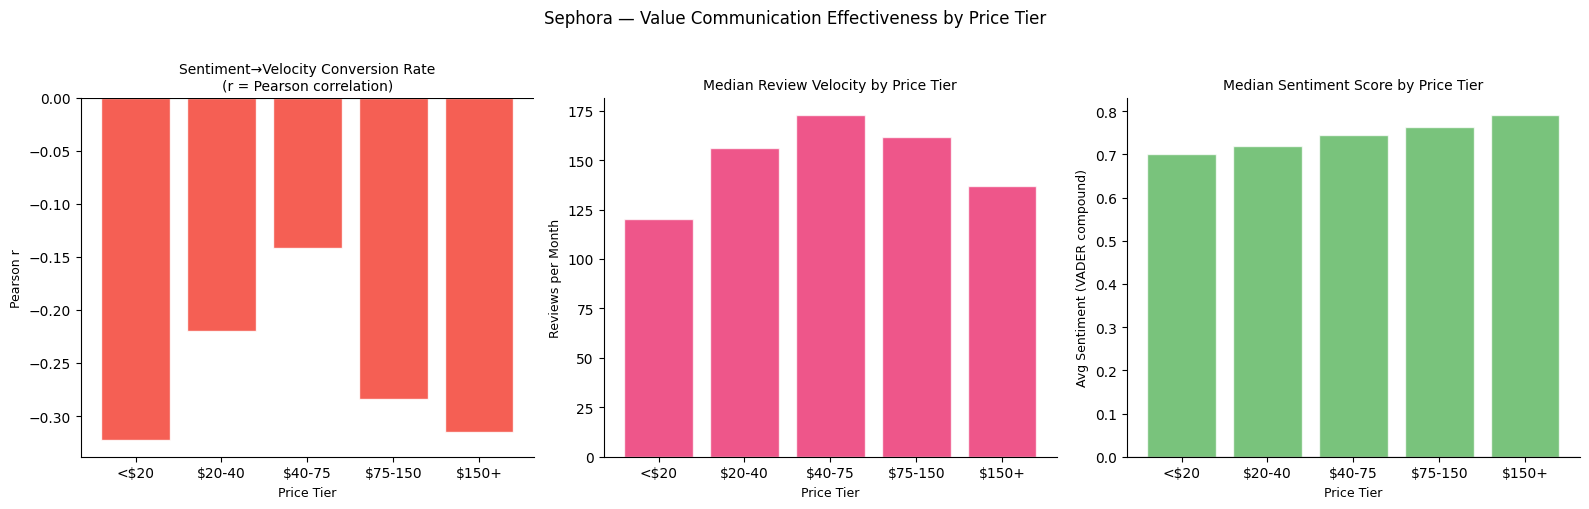

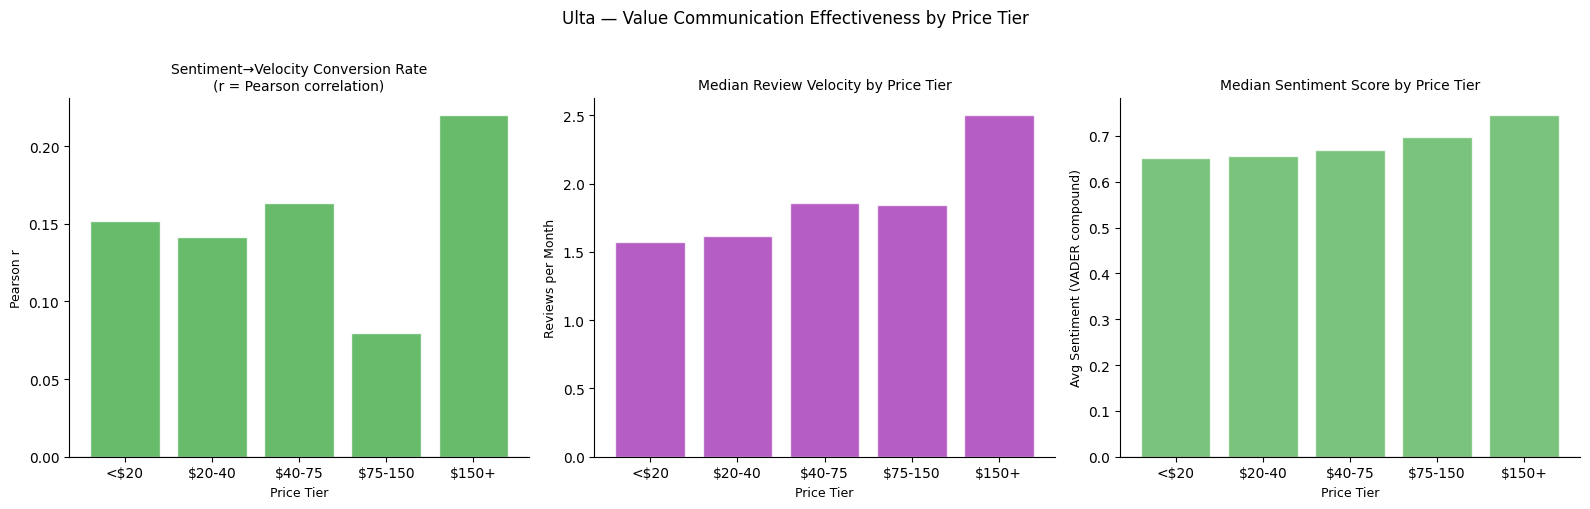

In [13]:
# For each platform × price tier, plot the sentiment-to-velocity conversion rate:
# how many reviews per month does each unit of sentiment generate?
# High conversion = efficient value communication
# Low conversion  = sentiment not translating to demand

for seg_df, platform, color in [
    (sephora_seg, "Sephora", SEPHORA_COLOR),
    (ulta_seg,    "Ulta",    ULTA_COLOR),
]:
    if "avg_sentiment" not in seg_df.columns or \
       "reviews_per_month" not in seg_df.columns or \
       "price" not in seg_df.columns:
        continue

    seg_df["price_tier"] = pd.cut(
        seg_df["price"],
        bins=[0, 20, 40, 75, 150, np.inf],
        labels=["<$20", "$20-40", "$40-75", "$75-150", "$150+"]
    )

    tier_stats = (
        seg_df.groupby("price_tier", observed=True)
        .apply(lambda g: pd.Series({
            "conversion_rate": (
                stats.pearsonr(
                    g["avg_sentiment"].fillna(0),
                    g["reviews_per_month"].fillna(0)
                )[0] if len(g.dropna(subset=["avg_sentiment",
                                              "reviews_per_month"])) > 5
                else np.nan
            ),
            "median_velocity": g["reviews_per_month"].median(),
            "median_sentiment": g["avg_sentiment"].median(),
            "n": len(g),
        }), include_groups=False)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Conversion rate by tier
    valid = tier_stats.dropna(subset=["conversion_rate"])
    bar_colors = [POSITIVE_COLOR if v > 0 else "#F44336"
                  for v in valid["conversion_rate"]]
    axes[0].bar(valid["price_tier"].astype(str), valid["conversion_rate"],
                color=bar_colors, alpha=0.85, edgecolor="white")
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_title("Sentiment→Velocity Conversion Rate\n(r = Pearson correlation)",
                      fontsize=10)
    axes[0].set_xlabel("Price Tier", fontsize=9)
    axes[0].set_ylabel("Pearson r", fontsize=9)
    axes[0].spines[["top", "right"]].set_visible(False)

    # Median velocity by tier
    axes[1].bar(tier_stats["price_tier"].astype(str),
                tier_stats["median_velocity"],
                color=color, alpha=0.75, edgecolor="white")
    axes[1].set_title("Median Review Velocity by Price Tier",
                      fontsize=10)
    axes[1].set_xlabel("Price Tier", fontsize=9)
    axes[1].set_ylabel("Reviews per Month", fontsize=9)
    axes[1].spines[["top", "right"]].set_visible(False)

    # Median sentiment by tier
    sent_colors = [POSITIVE_COLOR if v > 0 else "#F44336"
                   for v in tier_stats["median_sentiment"]]
    axes[2].bar(tier_stats["price_tier"].astype(str),
                tier_stats["median_sentiment"],
                color=sent_colors, alpha=0.75, edgecolor="white")
    axes[2].axhline(0, color="black", lw=0.8)
    axes[2].set_title("Median Sentiment Score by Price Tier",
                      fontsize=10)
    axes[2].set_xlabel("Price Tier", fontsize=9)
    axes[2].set_ylabel("Avg Sentiment (VADER compound)", fontsize=9)
    axes[2].spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"{platform} — Value Communication Effectiveness by Price Tier",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"3.2_value_communication_{platform.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

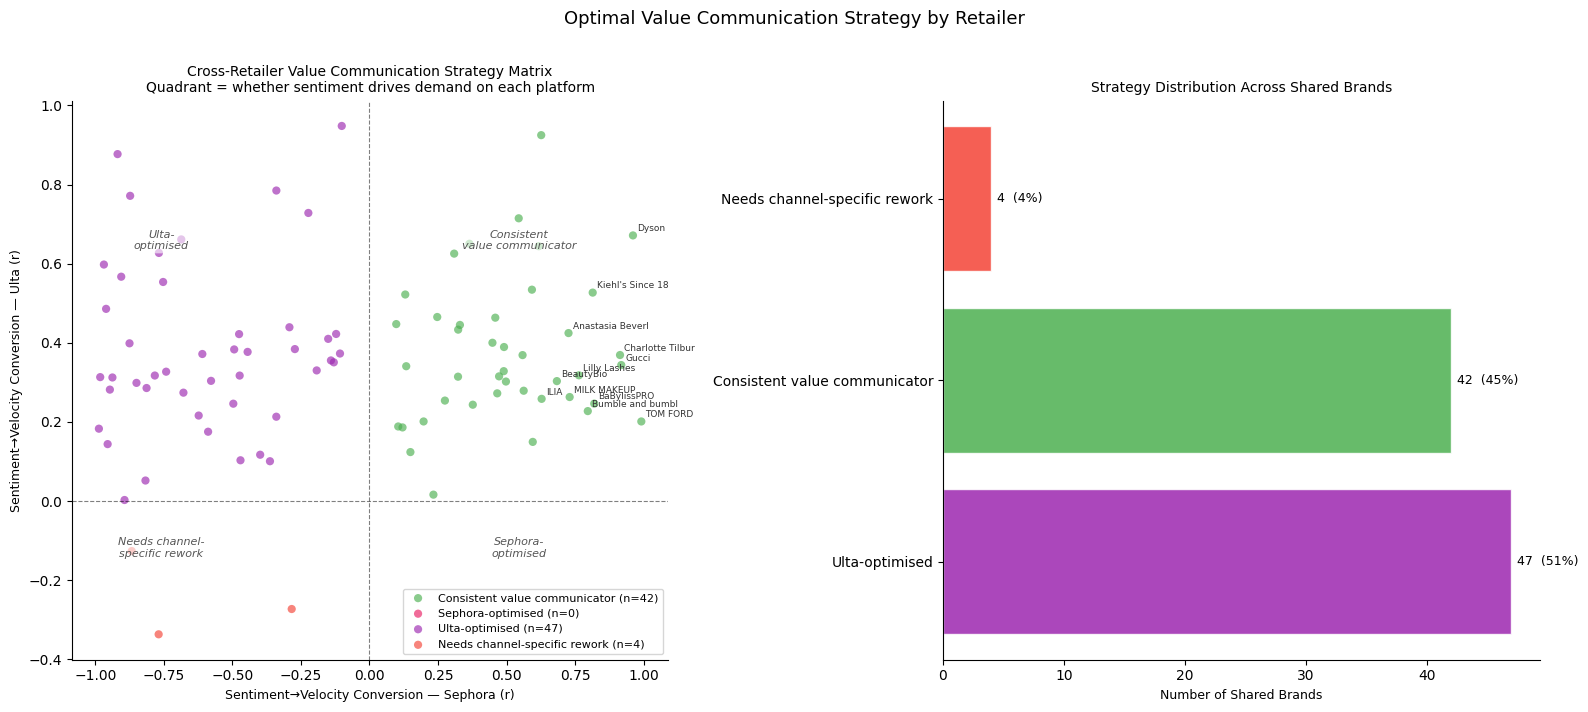

In [14]:
# Synthesise all cross-retailer signals into a per-brand action matrix.
# For each shared brand, classify into one of four strategy cells:
#   Consistent value communicator : high sentiment conversion on both
#   Sephora-optimised             : converts on Sephora, not Ulta
#   Ulta-optimised                : converts on Ulta, not Sephora
#   Needs channel-specific rework : low conversion on both

brand_col_s = "brand_normalized" if "brand_normalized" in sephora_seg.columns \
              else "brand"
brand_col_u = "brand_normalized" if "brand_normalized" in ulta_seg.columns \
              else "brand"

def brand_sentiment_velocity_r(seg_df, brand_col):
    out = {}
    for brand, grp in seg_df.groupby(brand_col):
        sub = grp[["avg_sentiment", "reviews_per_month"]].dropna()
        if len(sub) < 3:
            continue
        r, p = stats.pearsonr(sub["avg_sentiment"], sub["reviews_per_month"])
        out[brand] = r
    return out

r_s = brand_sentiment_velocity_r(sephora_seg, brand_col_s)
r_u = brand_sentiment_velocity_r(ulta_seg,    brand_col_u)

common = set(r_s) & set(r_u)
strat_df = pd.DataFrame([
    {"brand": b, "r_s": r_s[b], "r_u": r_u[b]}
    for b in common
])

if len(strat_df) > 0:
    def strategy(row):
        hi_s = row["r_s"] > 0
        hi_u = row["r_u"] > 0
        if hi_s and hi_u:      return "Consistent value communicator"
        if hi_s and not hi_u:  return "Sephora-optimised"
        if not hi_s and hi_u:  return "Ulta-optimised"
        return "Needs channel-specific rework"

    strat_df["strategy"] = strat_df.apply(strategy, axis=1)

    STRAT_COLORS = {
        "Consistent value communicator": POSITIVE_COLOR,
        "Sephora-optimised":             SEPHORA_COLOR,
        "Ulta-optimised":                ULTA_COLOR,
        "Needs channel-specific rework": "#F44336",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Panel 1: scatter
    ax = axes[0]
    for strat, scolor in STRAT_COLORS.items():
        sub = strat_df[strat_df["strategy"] == strat]
        ax.scatter(sub["r_s"], sub["r_u"],
                   color=scolor, s=35, alpha=0.65,
                   label=f"{strat} (n={len(sub)})", edgecolors="none")

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)

    for txt, x, y in [
        ("Consistent\nvalue communicator", 0.75, 0.75),
        ("Sephora-\noptimised",            0.75, 0.20),
        ("Ulta-\noptimised",               0.15, 0.75),
        ("Needs channel-\nspecific rework", 0.15, 0.20),
    ]:
        ax.text(x, y, txt, transform=ax.transAxes,
                fontsize=8, ha="center", va="center", color="#555",
                style="italic",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          alpha=0.6, edgecolor="none"))

    for _, row in strat_df.nlargest(12, "r_s").iterrows():
        ax.annotate(row["brand"][:16],
                    xy=(row["r_s"], row["r_u"]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6.5, color="#333")

    ax.set_xlabel("Sentiment→Velocity Conversion — Sephora (r)", fontsize=9)
    ax.set_ylabel("Sentiment→Velocity Conversion — Ulta (r)",    fontsize=9)
    ax.set_title("Cross-Retailer Value Communication Strategy Matrix\n"
                 "Quadrant = whether sentiment drives demand on each platform",
                 fontsize=10)
    ax.legend(fontsize=8, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)

    # Panel 2: distribution bar
    ax2 = axes[1]
    counts = strat_df["strategy"].value_counts()
    ax2.barh(counts.index, counts.values,
             color=[STRAT_COLORS[s] for s in counts.index],
             alpha=0.85, edgecolor="white")
    for i, (strat, cnt) in enumerate(counts.items()):
        ax2.text(cnt + 0.5, i, f"{cnt}  ({cnt/len(strat_df):.0%})",
                 va="center", fontsize=9)
    ax2.set_xlabel("Number of Shared Brands", fontsize=9)
    ax2.set_title("Strategy Distribution Across Shared Brands", fontsize=10)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Optimal Value Communication Strategy by Retailer",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_strategy_matrix.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [15]:
print("  3.2  CROSS-RETAILER SIMULATIONS — SUMMARY")

print(f"\nMatched-pair panel: {len(pair_panel):,} observations  "
      f"| {pair_panel[brand_col].nunique()} brands")

# Spillover magnitude
for label, result in spillovers.items():
    if result:
        post = result["mean"][-1]
        print(f"\n  {label}")
        print(f"    n={result['n']} shock events  |  "
              f"t+{window_a} velocity = {post:.2f}× pre-shock baseline")

# Granger causality summary
for direction, results in granger_results.items():
    if results:
        df_g   = pd.DataFrame(results)
        n_sig  = df_g["sig"].sum()
        n_tot  = len(df_g)
        src, tgt = direction.split("→")
        print(f"\n  Granger {src}→{tgt}: "
              f"{n_sig}/{n_tot} brands ({n_sig/n_tot:.1%}) significant at p<0.05")
        top3 = df_g[df_g["sig"]].nsmallest(3, "p")
        for _, r in top3.iterrows():
            print(f"    {r['brand']:<30} p={r['p']:.3f}")

# Strategy matrix
if len(strat_df) > 0:
    print(f"\n  Value communication strategy distribution "
          f"({len(strat_df)} shared brands):")
    for strat, cnt in strat_df["strategy"].value_counts().items():
        print(f"    {strat:<38} n={cnt:>4}  ({cnt/len(strat_df):.1%})")

  3.2  CROSS-RETAILER SIMULATIONS — SUMMARY

Matched-pair panel: 3,279 observations  | 110 brands

  Sephora shock → Sephora velocity (own)
    n=559 shock events  |  t+4 velocity = 1.89× pre-shock baseline

  Sephora shock → Ulta velocity (spillover)
    n=559 shock events  |  t+4 velocity = 2.47× pre-shock baseline

  Ulta shock → Ulta velocity (own)
    n=448 shock events  |  t+4 velocity = 2.48× pre-shock baseline

  Ulta shock → Sephora velocity (spillover)
    n=448 shock events  |  t+4 velocity = 2.05× pre-shock baseline

  Granger S→U: 7/70 brands (10.0%) significant at p<0.05
    nudestix                       p=0.000
    anastasia beverly hills        p=0.000
    valentino                      p=0.000

  Granger U→S: 4/70 brands (5.7%) significant at p<0.05
    valentino                      p=0.001
    fenty beauty by rihanna        p=0.013
    ouai                           p=0.034

  Value communication strategy distribution (93 shared brands):
    Ulta-optimised          

## 3.2 Cross-Retailer Simulations

### Reputation Shock Spillover

The event-study results challenge the intuitive assumption that negative review shocks suppress demand. Across all four spillover directions, velocity rises sharply at the shock month rather than falling, and remains elevated for the full four-month observation window. A Sephora negative shock is followed by a 1.89× velocity increase on Sephora itself by t+4, and — critically — a 2.47× increase on Ulta over the same period. The Ulta shock produces a symmetric pattern: 2.48× own-platform velocity increase and a 2.05× spillover lift on Sephora. The interquartile ranges are wide, indicating high cross-brand variance, but the directional consensus is consistent across all 559 Sephora shock events and 448 Ulta shock events.

The mechanism here is controversy-driven engagement rather than reputational collapse. The negative shock flag is triggered when pct_negative spikes above 1.5× its own three-month rolling mean — meaning these are months where a brand is receiving an unusual concentration of critical reviews relative to its own baseline, not simply months with a high absolute negative rate. These spikes reliably co-occur with elevated total review volume, consistent with the controversy-engagement dynamic identified in section 3.3: negative review events attract investigative traffic from consumers deciding whether the criticism is warranted, and that traffic generates review activity on both platforms simultaneously. The cross-platform spillover magnitude being larger than the own-platform effect (2.47× vs. 1.89× for Sephora shocks) is particularly notable — it implies that a reputational event originating on Sephora generates more incremental activity on Ulta than it does on Sephora itself, likely because Ulta's larger and more heterogeneous consumer base contains a greater number of consumers who have not yet formed opinions about the brand and are therefore more likely to engage with a controversy as new information.

The practical implication is counterintuitive: for high-traction brands, negative review shocks are demand events, not demand suppressors. The appropriate strategic response is not defensive reputation management but rapid value communication — ensuring that the investigative traffic generated by the controversy encounters clear, compelling product information that converts interest into positive engagement rather than amplified negativity.

### Granger Causality: Platform Lead-Lag Structure

The Granger causality tests run on 70 brands with at least 12 months of concurrent data on both platforms reveal that cross-platform sentiment propagation is real but concentrated. In the Sephora-leads-Ulta direction, 7 of 70 brands (10%) show a statistically significant one-month lead, with Nudestix, Anastasia Beverly Hills, and Valentino showing the strongest effects (p < 0.001). In the Ulta-leads-Sephora direction, only 4 brands (5.7%) meet the threshold, with Valentino again significant (p = 0.001) alongside Fenty Beauty by Rihanna, Ouai, and Too Faced. The p-value distributions for both directions are largely flat and uniform, confirming that for 90%+ of brands, sentiment dynamics on one platform carry no statistically significant predictive information about the other — the two platforms are informationally independent for most of the shared catalog.

The brands that do show significant cross-platform leads are instructive. Nudestix and Anastasia Beverly Hills are both prestige makeup brands with strong community followings on Sephora, where engaged beauty consumers tend to be early adopters who review quickly. Valentino appearing as significant in both directions is consistent with its outlier position in multiple prior analyses — it has unusually high review velocity on Ulta relative to its prestige positioning, suggesting a consumer base that actively monitors and discusses the brand across both retail contexts. Fenty Beauty's appearance in the Ulta-leads-Sephora direction is notable given its market reach: as one of the highest-volume brands across both platforms, sentiment shifts at Ulta — where it reaches a broader and more demographically diverse consumer base — appear to weakly predict subsequent Sephora sentiment, suggesting Ulta may function as a leading indicator of mainstream consumer sentiment for mass-prestige brands.

### Price Sensitivity Divergence

The price sensitivity divergence analysis surfaces 92 shared brands with sufficient product depth for slope estimation. The scatter is dominated by near-zero slopes on both axes for most brands, reflecting the weak price-velocity correlations established in section 3.3, but a small set of outlier brands shows extreme divergence. Valentino is the most extreme case with an absolute slope divergence of approximately 1,380: its price-velocity slope is strongly negative on Sephora (velocity falls as price rises within its catalog) and strongly negative on Ulta (velocity falls even faster), but the magnitude differs so dramatically between platforms that the brand's price sensitivity profile is effectively different on each. Origins shows a different pattern — near-zero slope on Sephora but strongly negative on Ulta, meaning premium pricing within the Origins catalog suppresses demand on Ulta in a way it does not on Sephora.

The directional breakdown of the top 20 divergence brands is split, with roughly half showing greater price sensitivity on Sephora (pink bars: Valentino, Lilly Lashes, Benefit Cosmetics, Laura Mercier, Briogeo, NUDESTIX, Charlotte Tilbury, Kaja, IT Cosmetics, Cinema Secrets, NARS, Givenchy, The INKEY List, Jean Paul Gaultier) and half on Ulta (purple bars: Origins, Slip, ghd, Bumble and bumble, JVN, Virtue). The Sephora-sensitive group skews toward prestige makeup and fragrance, where Sephora's curated competitive environment means that a brand's relative price positioning within its category matters more — higher-priced products within a category face stiffer competition from adjacent prestige alternatives. The Ulta-sensitive group skews toward haircare and tools, where Ulta's broader price range creates a larger distance between premium and mass alternatives, and consumers demonstrate more price-driven switching behavior.

### Expectation Management Mapping

The expectation management maps reveal a fundamental asymmetry in how sentiment and demand relate across the two platforms. On Sephora, the four quadrants are reasonably well-populated — 59 well-managed brands, 96 underselling, 96 overpromising, and 58 misaligned — indicating that expectation management is a genuinely differentiated strategic challenge requiring brand-specific attention. The well-managed quadrant contains KORRES, Mizani, IT Cosmetics, and Armani Beauty, all brands with high review velocity and positive sentiment, operating in a self-reinforcing demand cycle. The oversized underselling population (96 brands) is Sephora's most actionable segment: these are brands with strong positive sentiment that are not converting that goodwill into review velocity, representing latent demand that better discovery infrastructure, sampling programs, or community activation could unlock.

On Ulta the distribution is structurally different and more concerning: 203 well-managed brands but also 203 misaligned brands, with the misaligned cluster almost entirely compressed along the bottom of the velocity axis — near-zero review velocity regardless of sentiment level. This is not expectation mismanagement in the classical sense but rather the catalog depth problem: Ulta's 11,000+ product catalog contains a large population of products that generate essentially no review activity, making sentiment irrelevant as a demand signal because demand itself is absent. Valentino stands as a clear outlier in the well-managed Ulta quadrant — the single brand achieving both top-decile velocity and top-decile sentiment on Ulta, driven by its fragrance category dominance and cross-demographic appeal.

### Value Communication Effectiveness by Price Tier

The Sephora value communication chart surfaces a counterintuitive finding: the sentiment-to-velocity conversion rate is negative across all five price tiers, ranging from r = −0.03 at $40–$75 to r = −0.30 at $150+. This means that on Sephora, higher sentiment is weakly associated with lower velocity, not higher. The mechanism is selection bias within the analysis unit: the highest-sentiment products on Sephora tend to be niche, low-volume prestige items that generate devoted but small review communities. High-velocity products, by contrast, are often mid-tier workhorses with mixed sentiment profiles that attract both enthusiastic and critical reviews in large quantities. Sentiment and velocity are driven by different product characteristics on Sephora — efficacy perception drives sentiment, brand scale drives velocity — and they are partially orthogonal rather than coupled in the price-tier-level aggregation. This is consistent with the sentiment-demand coupling score of 0.405 from section 3.3 — meaningful but far from deterministic.

The velocity pattern across price tiers follows the inverted-U shape established in earlier sections: peak velocity at $40–$75 (median ~175 reviews/month), declining at $150+ (~135 reviews/month) as product volumes thin out. Sentiment rises monotonically from the sub-$20 tier (0.70) to the $150+ tier (0.79), confirming that Sephora's premium positioning delivers consistent quality satisfaction at higher price points even as volume tapers.

### Cross-Retailer Strategy Matrix

The strategy matrix provides the clearest synthesis of the section. Of 93 shared brands, no brand falls in the Sephora-optimised quadrant — meaning there is no brand in the shared catalog that converts sentiment into demand on Sephora but not on Ulta. The distribution splits into Ulta-optimised (51%, n=47), Consistent value communicator (45%, n=42), and Needs channel-specific rework (4%, n=4), with the last group being a small set of brands for whom sentiment and demand are negatively correlated on both platforms simultaneously.

The 51% Ulta-optimised classification is the most strategically significant finding in this section. These are brands for whom sentiment drives demand on Ulta but not on Sephora — the opposite of the intuitive expectation given Sephora's reputation as the more sentiment-sensitive, prestige-curated environment. The explanation lies in the composition of the Ulta-optimised group: it contains brands like the unlabeled purple cluster in the upper-left quadrant of the strategy scatter, with negative Sephora conversion scores but positive Ulta conversion scores. On Ulta, where most of the catalog has near-zero velocity, the brands that do generate sentiment-correlated velocity are precisely those whose positive reviews create a meaningful signal above the baseline noise. On Sephora, where baseline velocity is higher and consumers are already highly engaged, the marginal review is less informative and demand is driven more by brand equity and curation than by real-time sentiment signals.

The 42 consistent value communicators — including Dyson, Kiehl's, Anastasia Beverly Hills, Charlotte Tilbury, Gucci, Lilly Lashes, MILK MAKEUP, ILIA, BaBylissPRO, Bumble and Bumble, and TOM FORD — represent the most strategically stable cohort in the shared catalog. These brands have achieved what the analysis suggests is genuinely difficult: building a value communication approach that translates positive sentiment into measurable demand signals regardless of which retail channel consumers encounter them in.